In [4]:
import h5py
import sys
sys.path.append('../../')
from utils import load_results_from_h5

In [5]:
data = load_results_from_h5('../../../../A-sharp-study/GWFish_analysis/BBH/Errors/CE4020ET123_CoBA10_2_PLP_z_MD_zmax_10_lmrd_22_no_spins_4402_events_pop_from_XPHM_fm2_netw2.h5')
    

In [22]:
from pycbc import conversions as convert
from pycbc import cosmology
import pandas as pd
inj_params = data['fm2_all_inj_params']
inj_params['redshift'] = cosmology.redshift(inj_params['luminosity_distance'])
inj_params['total_mass_source'] = (convert.mtotal_from_mchirp_eta(inj_params['chirp_mass'], 
                                                                  convert.eta_from_q(1/inj_params['mass_ratio']))) / (1+inj_params['redshift']) 
mask_gt_80 = (inj_params['total_mass_source'] > 80)
inj_params = pd.DataFrame(inj_params)
inj_params[mask_gt_80]

,a_1,a_2,chirp_mass,dec,geocent_time,luminosity_distance,mass_ratio,phase,phi_12,phi_jl,psi,ra,theta_jn,tilt_1,tilt_2,total_mass,redshift,total_mass_source
99,0.689230,0.359920,99.872564,-0.507677,1.893656e+09,6975.521355,0.790473,2.185533,2.276298,1.192888,1.691305,0.083694,2.000789,2.136088,2.083139,231.353088,1.021884,114.424502
113,0.197690,0.823133,77.917455,-0.108191,1.901704e+09,6801.089098,0.998362,1.819425,3.342062,3.248867,0.627637,2.035687,0.943391,1.778500,0.880448,179.007376,1.001108,89.454128
155,0.978715,0.705557,88.451117,0.464189,1.915283e+09,7917.696280,0.716790,5.170968,0.887914,6.273712,2.697282,6.157270,1.944700,1.425510,2.021873,206.599250,1.132416,96.885048
279,0.845292,0.690791,133.226396,0.558543,1.913133e+09,20893.805167,0.728852,2.541431,3.458752,3.636729,0.915960,4.728348,1.484831,0.714034,1.307303,310.681967,2.499283,88.784453
438,0.100267,0.387117,139.691006,1.506823,1.900404e+09,13846.405994,0.866404,3.810279,3.247039,4.754062,2.800527,5.106401,1.180420,1.338433,0.593543,321.916300,1.783042,115.670646
478,0.172518,0.168488,120.097034,0.874822,1.917715e+09,17082.135362,0.788058,1.640899,1.755211,2.473140,2.100996,4.225051,0.661357,1.757970,1.382761,278.262883,2.117338,89.262991
733,0.167293,0.637155,194.623507,1.131122,1.911066e+09,33377.690780,0.457585,4.793599,1.738251,2.185736,2.357639,1.760561,0.913854,1.365808,0.748145,488.959440,3.692876,104.191857
754,0.488530,0.989309,135.245791,-0.066538,1.917438e+09,26933.250682,0.475535,0.157700,0.022532,0.392252,0.109743,4.884642,1.618214,2.094786,1.006456,336.940841,3.085605,82.470247
764,0.980768,0.239821,121.300952,-0.696297,1.915793e+09,9445.938695,0.771910,4.171900,2.305007,1.795439,0.687446,1.457321,1.511367,0.787596,2.453065,281.484318,1.306565,122.036142
995,0.526128,0.522685,97.922626,0.525632,1.915917e+09,11545.290984,0.647944,0.086572,2.586168,0.651085,1.934791,3.971176,1.405028,2.572652,1.167117,231.361731,1.537742,91.168357


In [23]:
data['fm2_netw_snrs']

array([27.89675882, 48.63961354, 12.32017399, ..., 80.76783461,
       89.50670169, 59.48064971])

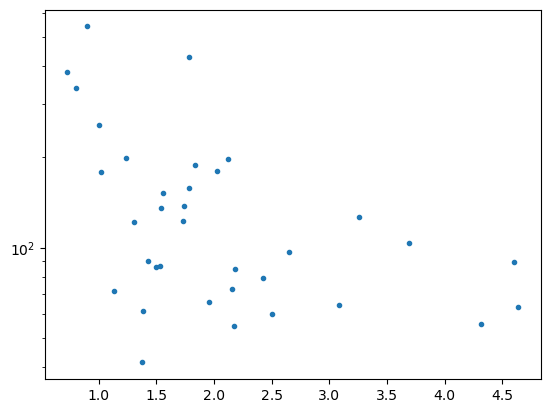

In [25]:
import pylab as plt
plt.plot(inj_params['redshift'][mask_gt_80], data['fm2_netw_snrs'][mask_gt_80], '.')
plt.yscale('log')

In [14]:
#project_dir = '/home/divyajyoti/ACADEMIC/Projects/Cardiff_University/Next_gen_detectability/A-sharp-study/gwpopulation/BBH/injections/'
source_file1 = '/home/divyajyoti/ACADEMIC/Projects/Cardiff_University/Next_gen_detectability/A-sharp-study/gwpopulation/BBH/posteriors_from_GWFish/mass_bands/LHI_Asharp_4_PLP_z_MDhigh_zp_2.53_zmax_10_lmrd_22_no_spins_posteriors_10K_313_events_pop_from_XPHM_fm2_netw_above_80.pkl'
source_file2 = '/home/divyajyoti/ACADEMIC/Projects/Cardiff_University/Next_gen_detectability/A-sharp-study/gwpopulation/BBH/posteriors_from_GWFish/mass_bands/LHI_Asharp_5_PLP_z_MDlow_zp_1.54_zmax_10_lmrd_22_no_spins_posteriors_10K_202_events_pop_from_XPHM_fm2_netw_above_80.pkl'
#source_file_path = os.path.join(project_dir, source_file)

In [15]:
with open(source_file1, 'rb') as f:
    source_data1 = dill.load(f)
with open(source_file2, 'rb') as f:
    source_data2 = dill.load(f)

In [16]:
med = []
for i in source_data1:
    med.append(np.median(i['redshift']))
med2 = []
for i in source_data2:
    med2.append(np.median(i['redshift']))

In [18]:
import pylab as plt
len(med), len(med2)

(313, 202)

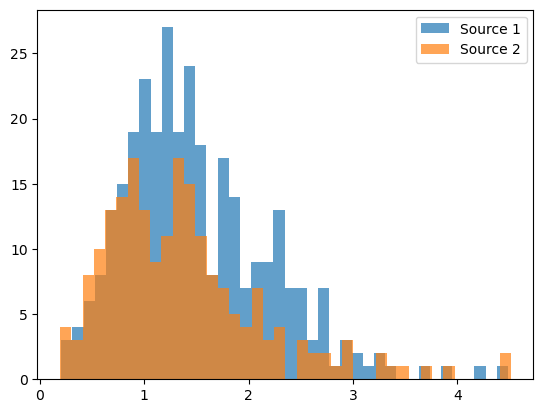

In [21]:
plt.hist(med, bins=40, label='Source 1', alpha=0.7)
plt.hist(med2, bins=40, label='Source 2', alpha=0.7)
plt.legend()
plt.show()